In [3]:
import sys
sys.path.append(r"C:\Users\Hp\Desktop\DL\da6401_assignment_1\src")


In [4]:
import numpy as np
import wandb
from utils.data_loader import load_data

# 1) Load dataset from your project loader
X_train, y_train, X_val, y_val, X_test, y_test = load_data("mnist")

# 2) Start run
run = wandb.init(
    project="da6401_assignment_1",
    name="q2_1_data_exploration_mnist",
    config={"question": "2.1", "dataset": "mnist", "samples_per_class": 5},
)

# 3) Build table: 5 images per class
# NOTE: your loader returns flattened images, so reshape back to 28x28 for display
table = wandb.Table(columns=["image", "class_id"])
for c in range(10):
    idx = np.where(y_train == c)[0][:5]
    for i in idx:
        img = (X_train[i].reshape(28, 28) * 255).astype(np.uint8)
        table.add_data(wandb.Image(img), int(c))

# 4) Log
wandb.log({"q2_1_class_samples_table": table})

# 5) Finish
wandb.finish()


C:\Users\Hp\AppData\Roaming\Python\Python313\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\Hp\AppData\Roaming\Python\Python313\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\Hp\AppData\Roaming\Python\Python313\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/resource_handle.proto. Please update th

In [2]:
import sys
import numpy as np
import wandb
from types import SimpleNamespace

sys.path.append(r"C:\Users\Hp\Desktop\DL\da6401_assignment_1\src")

from utils.data_loader import load_data
from ann.neural_network import NeuralNetwork


C:\Users\Hp\AppData\Roaming\Python\Python313\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\Hp\AppData\Roaming\Python\Python313\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\Hp\AppData\Roaming\Python\Python313\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/resource_handle.proto. Please update th

In [3]:
PROJECT = "da6401_assignment_1"

HIDDEN_OPTIONS = [
    [64], [128],
    [64,64], [128,64], [128,128],
    [64,64,64], [128,64,64], [128,128,64], [128,128,128],
    [128,128,128,64], [128,128,128,128],
    [128,128,128,128,64], [128,128,128,128,128],
    [128,128,128,128,128,64], [128,128,128,128,128,128],
]

sweep_config = {
    "method": "bayes",
    "metric": {"name": "val_accuracy", "goal": "maximize"},
    "parameters": {
        "dataset": {"values": ["mnist"]},
        "epochs": {"values": [10, 15]},
        "batch_size": {"values": [32, 64, 128]},
        "loss": {"values": ["cross_entropy", "mse"]},
        "optimizer": {"values": ["sgd", "momentum", "nag", "rmsprop"]},
        "learning_rate": {"values": [1e-4, 5e-4, 1e-3, 5e-3, 1e-2]},
        "weight_decay": {"values": [0.0, 1e-5, 1e-4]},
        "activation": {"values": ["relu", "tanh", "sigmoid"]},
        "weight_init": {"values": ["random", "xavier"]},
        "hidden_size": {"values": HIDDEN_OPTIONS},
    },
}

sweep_id = wandb.sweep(sweep_config, project=PROJECT)
print("Sweep ID:", sweep_id)


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\Hp\_netrc.


Create sweep with ID: n50xaeh9
Sweep URL: https://wandb.ai/sai-sathwik/da6401_assignment_1/sweeps/n50xaeh9
Sweep ID: n50xaeh9


In [ ]:
def run_train_notebook():
    with wandb.init() as run:
        c = run.config

        # Build args-like object expected by NeuralNetwork
        args = SimpleNamespace(
            dataset=c.dataset,
            epochs=int(c.epochs),
            batch_size=int(c.batch_size),
            loss=c.loss,
            optimizer=c.optimizer,
            learning_rate=float(c.learning_rate),
            weight_decay=float(c.weight_decay),
            hidden_size=list(c.hidden_size),
            num_layers=len(c.hidden_size),
            activation=c.activation,
            weight_init=c.weight_init,
            wandb_project=PROJECT,
            model_save_path="src/best_model.npy",
        )

        X_train, y_train, X_val, y_val,_,_ = load_data(args.dataset)

        model = NeuralNetwork(args)

        best_val_acc = -1.0
        for epoch in range(args.epochs):
            model.train(X_train, y_train, epochs=1, batch_size=args.batch_size, X_val=X_val, y_val=y_val)

            val_metrics = model.evaluate(X_val, y_val)

            wandb.log({
                "epoch": epoch + 1,
                "val_loss": val_metrics["loss"],
                "val_accuracy": val_metrics["accuracy"],
                "val_precision": val_metrics["precision"],
                "val_recall": val_metrics["recall"],
                "val_f1": val_metrics["f1"],
                
            })

            if val_metrics["accuracy"] > best_val_acc:
                best_val_acc = val_metrics["accuracy"]


In [5]:
wandb.agent(sweep_id, function=run_train_notebook, count=100)


wandb: Agent Starting Run: uvb12pe5 with config:
wandb: 	activation: relu
wandb: 	batch_size: 64
wandb: 	dataset: mnist
wandb: 	epochs: 10
wandb: 	hidden_size: [128]
wandb: 	learning_rate: 0.005
wandb: 	loss: cross_entropy
wandb: 	optimizer: rmsprop
wandb: 	weight_decay: 0
wandb: 	weight_init: xavier
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\Hp\_netrc.
wandb: Currently logged in as: saisathwik005 (sai-sathwik) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


epoch,▁▂▃▃▄▅▆▆▇█
val_accuracy,▁▅▆▆▇▆▇▇█▆
val_f1,▁▅▆▆▇▆▇▇█▆
val_loss,█▂▂▂▁▃▂▃▂▆
val_precision,▁▅▆▆▇▆▇▇█▆
val_recall,▁▅▆▆▇▆▇▇█▆
epoch,10
val_accuracy,0.96317
val_f1,0.96268
val_loss,0.18175
val_precision,0.96341


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: jaoc4tur with config:
wandb: 	activation: relu
wandb: 	batch_size: 32
wandb: 	dataset: mnist
wandb: 	epochs: 15
wandb: 	hidden_size: [128, 64]
wandb: 	learning_rate: 0.0001
wandb: 	loss: mse
wandb: 	optimizer: sgd
wandb: 	weight_decay: 0.0001
wandb: 	weight_init: random
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\Hp\_netrc.


epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
val_accuracy,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_f1,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,█▇▇▆▆▅▄▄▃▃▃▂▂▁▁
val_precision,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_recall,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,15
val_accuracy,0.11233
val_f1,0.0202
val_loss,0.89976
val_precision,0.01123


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: mah19xvo with config:
wandb: 	activation: sigmoid
wandb: 	batch_size: 64
wandb: 	dataset: mnist
wandb: 	epochs: 10
wandb: 	hidden_size: [128, 64, 64]
wandb: 	learning_rate: 0.0005
wandb: 	loss: cross_entropy
wandb: 	optimizer: rmsprop
wandb: 	weight_decay: 1e-05
wandb: 	weight_init: random
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\Hp\_netrc.


...

epoch,▁▂▃▃▄▅▆▆▇█
val_accuracy,▁▄▆▆▇▇████
val_f1,▁▄▆▆▇▇████
val_loss,█▆▄▃▃▂▂▁▁▁
val_precision,▁▄▆▇▇▇████
val_recall,▁▄▆▆▇▇████
epoch,10
val_accuracy,0.85183
val_f1,0.84924
val_loss,0.61457
val_precision,0.85267


wandb: Agent Starting Run: i3um55sr with config:
wandb: 	activation: tanh
wandb: 	batch_size: 128
wandb: 	dataset: mnist
wandb: 	epochs: 10
wandb: 	hidden_size: [64, 64, 64]
wandb: 	learning_rate: 0.0001
wandb: 	loss: cross_entropy
wandb: 	optimizer: rmsprop
wandb: 	weight_decay: 1e-05
wandb: 	weight_init: xavier
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\Hp\_netrc.


epoch,▁▂▃▃▄▅▆▆▇█
val_accuracy,▁▃▄▅▆▆▇▇▇█
val_f1,▁▃▄▅▆▆▇▇▇█
val_loss,█▆▅▄▃▃▂▂▁▁
val_precision,▁▃▄▅▆▆▇▇▇█
val_recall,▁▃▄▅▆▆▇▇▇█
epoch,10
val_accuracy,0.94983
val_f1,0.94948
val_loss,0.17107
val_precision,0.94969


wandb: Agent Starting Run: 2q33iy61 with config:
wandb: 	activation: sigmoid
wandb: 	batch_size: 128
wandb: 	dataset: mnist
wandb: 	epochs: 10
wandb: 	hidden_size: [128, 128, 128, 128, 64]
wandb: 	learning_rate: 0.0005
wandb: 	loss: cross_entropy
wandb: 	optimizer: rmsprop
wandb: 	weight_decay: 0.0001
wandb: 	weight_init: random
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\Hp\_netrc.


epoch,▁▂▃▃▄▅▆▆▇█
val_accuracy,▁▃▅▆▆▆▆▆▇█
val_f1,▁▃▆▆▆▆▇▇██
val_loss,█▅▄▃▂▂▂▂▂▁
val_precision,▁▄▆█▇▇▇▇██
val_recall,▁▃▅▆▆▆▆▆▇█
epoch,10
val_accuracy,0.545
val_f1,0.46663
val_loss,1.18044
val_precision,0.44766


In [1]:
import os
os.environ["PYTHONUTF8"] = "1"


In [2]:
# Q2.3 Optimizer Showdown (without calling train.py)
# Fixed architecture: 3 hidden layers, 128 neurons each, ReLU
# Compare: sgd, momentum, nag, rmsprop over first 5 epochs

import os
import sys
from types import SimpleNamespace

import numpy as np
import wandb

REPO_ROOT = r"C:\Users\Hp\Desktop\DL\da6401_assignment_1"
PROJECT = "da6401_assignment_1"

src_path = os.path.join(REPO_ROOT, "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

from ann.neural_network import NeuralNetwork
from utils.data_loader import load_data

optimizers = ["sgd", "momentum", "nag", "rmsprop"]
X_train, y_train, X_val, y_val, X_test, y_test = load_data("mnist")

for opt in optimizers:
    run = wandb.init(
        project=PROJECT,
        name=f"q2_3_{opt}",
        group="q2_3_final",
        tags=["q2_3", "optimizer-showdown", opt, "mnist", "relu", "3x128"],
        reinit=True,
    )

    args = SimpleNamespace(
        dataset="mnist",
        epochs=5,
        batch_size=64,
        loss="cross_entropy",
        optimizer=opt,
        learning_rate=0.001,
        weight_decay=0.0,
        hidden_size=[128, 128, 128],
        num_layers=3,
        activation="relu",
        weight_init="xavier",
        wandb_project=PROJECT,
        model_save_path=f"src/q2_3_{opt}.npy",
    )

    model = NeuralNetwork(args)
    best_val_f1 = -1.0
    best_weights = None

    for epoch in range(args.epochs):
        model.train(X_train, y_train, epochs=1, batch_size=args.batch_size, X_val=X_val, y_val=y_val)

        val_metrics = model.evaluate(X_val, y_val)
        test_metrics = model.evaluate(X_test, y_test)

        wandb.log({
            "epoch": epoch + 1,
            "val_loss": val_metrics["loss"],
            "val_accuracy": val_metrics["accuracy"],
            "val_precision": val_metrics["precision"],
            "val_recall": val_metrics["recall"],
            "val_f1": val_metrics["f1"],
            "test_loss": test_metrics["loss"],
            "test_accuracy": test_metrics["accuracy"],
            "test_precision": test_metrics["precision"],
            "test_recall": test_metrics["recall"],
            "test_f1": test_metrics["f1"],
        })

        if val_metrics["f1"] > best_val_f1:
            best_val_f1 = val_metrics["f1"]


    wandb.summary["best_val_f1"] = best_val_f1
    wandb.finish()


epoch,▁▃▅▆█
test_accuracy,▁▄▇██
test_f1,▁▄▇██
test_loss,█▆▃▂▁
test_precision,▁▅▇██
test_recall,▁▄▇██
val_accuracy,▁▄▇██
val_f1,▁▄▇██
val_loss,█▆▃▂▁
val_precision,▁▅▇██
+1,...


epoch,▁▃▅▆█
test_accuracy,▁▄▆▇█
test_f1,▁▄▆▇█
test_loss,█▆▄▂▁
test_precision,▁▄▆▇█
test_recall,▁▄▆▇█
val_accuracy,▁▄▆▇█
val_f1,▁▄▆▇█
val_loss,█▆▄▂▁
val_precision,▁▅▆▇█
+1,...


epoch,▁▃▅▆█
test_accuracy,▁▅▇██
test_f1,▁▅▇██
test_loss,█▆▃▂▁
test_precision,▁▄▆▇█
test_recall,▁▅▇██
val_accuracy,▁▄▇▇█
val_f1,▁▄▇██
val_loss,█▆▃▂▁
val_precision,▁▅▇██
+1,...


epoch,▁▃▅▆█
test_accuracy,▁▅▆▆█
test_f1,▁▅▆▆█
test_loss,█▃▁▃▂
test_precision,▁▅▆▆█
test_recall,▁▅▆▆█
val_accuracy,▁▄▇▄█
val_f1,▁▄▇▄█
val_loss,█▄▂▄▁
val_precision,▁▄▇▄█
+1,...


In [5]:
# Q2.4 Vanishing Gradient Analysis (without calling train.py)
# Fix optimizer = RMSProp, compare Sigmoid vs ReLU for different network configs
# Track grad_norm_layer1 vs epoch

import os
import sys
from types import SimpleNamespace

import numpy as np
import wandb

REPO_ROOT = r"C:\Users\Hp\Desktop\DL\da6401_assignment_1"
PROJECT = "da6401_assignment_1"

src_path = os.path.join(REPO_ROOT, "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

from ann.neural_network import NeuralNetwork
from utils.data_loader import load_data

configs = [
    [128, 128],
    [128, 128, 128],
    [128, 128, 128, 128],
]

X_train, y_train, X_val, y_val, X_test, y_test = load_data("mnist")

for hidden in configs:
    nhl = len(hidden)
    arch_name = "x".join(str(x) for x in hidden)

    for act in ["sigmoid", "relu"]:
        run = wandb.init(
            project=PROJECT,
            name=f"q2_4_{act}_{arch_name}",
            group="q2_4",
            tags=["q2_4", "vanishing-gradient", "rmsprop", act, f"arch_{arch_name}"],
            config={
                "question": "2.4",
                "optimizer": "rmsprop",
                "activation": act,
                "hidden_size": hidden,
                "num_layers": nhl,
                "epochs": 10,
                "dataset": "mnist",
            },
            reinit=True,
        )

        args = SimpleNamespace(
            dataset="mnist",
            epochs=10,
            batch_size=64,
            loss="cross_entropy",
            optimizer="rmsprop",
            learning_rate=0.001,
            weight_decay=0.0,
            hidden_size=hidden,
            num_layers=nhl,
            activation=act,
            weight_init="xavier",
            wandb_project=PROJECT,
            model_save_path=f"src/q2_4_{act}_{arch_name}.npy",
        )

        model = NeuralNetwork(args)
        best_val_f1 = -1.0
        best_weights = None

        for epoch in range(args.epochs):
            model.train(
                X_train,
                y_train,
                epochs=1,
                batch_size=args.batch_size,
                X_val=X_val,
                y_val=y_val,
            )

            val_metrics = model.evaluate(X_val, y_val)
            test_metrics = model.evaluate(X_test, y_test)

            grad_norm_layer1 = None
            if len(model.layers) > 0 and model.layers[0].grad_W is not None:
                grad_norm_layer1 = float(np.linalg.norm(model.layers[0].grad_W))

            wandb.log({
                "epoch": epoch + 1,
                "val_loss": val_metrics["loss"],
                "val_accuracy": val_metrics["accuracy"],
                "val_precision": val_metrics["precision"],
                "val_recall": val_metrics["recall"],
                "val_f1": val_metrics["f1"],
                "test_loss": test_metrics["loss"],
                "test_accuracy": test_metrics["accuracy"],
                "test_precision": test_metrics["precision"],
                "test_recall": test_metrics["recall"],
                "test_f1": test_metrics["f1"],
                "grad_norm_layer1": grad_norm_layer1,
            })

            if val_metrics["f1"] > best_val_f1:
                best_val_f1 = val_metrics["f1"]
                best_weights = model.get_weights()

        if best_weights is None:
            best_weights = model.get_weights()
        np.save(
            os.path.join(REPO_ROOT, f"src/q2_4_{act}_{arch_name}.npy"),
            best_weights,
            allow_pickle=True,
        )

        wandb.summary["best_val_f1"] = best_val_f1
        wandb.finish()


epoch,▁▂▃▃▄▅▆▆▇█
grad_norm_layer1,▅▅▂▃▄▂▁█▄▃
test_accuracy,▁▄▅▆▇▇▇▇██
test_f1,▁▄▅▆▇▇▇▇██
test_loss,█▅▃▂▂▁▁▁▁▁
test_precision,▁▄▅▆▇▇▇▇██
test_recall,▁▄▅▆▇▇▇▇██
val_accuracy,▁▄▅▆▇▇█▇██
val_f1,▁▄▅▆▇▇█▇██
val_loss,█▅▃▃▂▂▂▂▁▁
+2,...


epoch,▁▂▃▃▄▅▆▆▇█
grad_norm_layer1,▄▁▇█▃▂▄▁▂▂
test_accuracy,▁▅▁▆▇▆█▇▇█
test_f1,▁▅▁▆▇▆█▇▇█
test_loss,█▃█▁▁▂▁▃▅▄
test_precision,▁▅▁▆▇▆█▇▇█
test_recall,▁▅▂▆▇▆█▇▇█
val_accuracy,▁▅▁▆▇▇█▇▇█
val_f1,▁▅▁▆▇██▇▇█
val_loss,▇▃█▂▁▂▂▄▅▄
+2,...


epoch,▁▂▃▃▄▅▆▆▇█
grad_norm_layer1,▆▅▂▂▆▇▆█▁▆
test_accuracy,▁▄▆▇▇▇▇███
test_f1,▁▄▆▇▇▇▇███
test_loss,█▄▃▂▁▂▂▁▁▂
test_precision,▁▅▆▇▇▇▇███
test_recall,▁▄▆▇▇▇▇███
val_accuracy,▁▅▆▇▇▇▇█▇█
val_f1,▁▅▆▇▇▇▇█▇█
val_loss,█▄▃▂▁▂▂▁▂▂
+2,...


epoch,▁▂▃▃▄▅▆▆▇█
grad_norm_layer1,▄█▂█▅▂▆▅▂▁
test_accuracy,▁▂▅▅▆▅▅▆▇█
test_f1,▁▂▅▅▆▅▅▆▇█
test_loss,█▆▃▂▁▄▄▃▃▁
test_precision,▁▂▅▅▇▅▅▆▇█
test_recall,▁▂▅▆▆▅▅▆▇█
val_accuracy,▁▂▅▆▆▅▅▆▆█
val_f1,▁▂▅▆▆▅▅▆▆█
val_loss,█▆▂▃▁▃▄▃▄▂
+2,...


epoch,▁▂▃▃▄▅▆▆▇█
grad_norm_layer1,▇▄▄▂▄▇▁▁▅█
test_accuracy,▁▄▆▆▇█▇██▇
test_f1,▁▄▆▆▇████▇
test_loss,█▅▃▂▁▁▁▁▁▂
test_precision,▁▄▆▆▇█▇██▇
test_recall,▁▄▆▆▇████▇
val_accuracy,▁▄▇▇▇▇███▇
val_f1,▁▄▇▇▇▇███▇
val_loss,█▅▃▂▂▁▁▁▂▂
+2,...


epoch,▁▂▃▃▄▅▆▆▇█
grad_norm_layer1,▇▆▂██▇▅▃▁▃
test_accuracy,▁▆▇▅▇▅███▇
test_f1,▁▆▇▅▇▆███▇
test_loss,█▃▁▃▃▃▂▁▂▃
test_precision,▁▆▇▅▆▆███▇
test_recall,▁▆▇▆▇▆███▇
val_accuracy,▁▅▇▅▇▆████
val_f1,▁▅▇▅▇▆████
val_loss,█▃▁▄▂▃▂▁▃▃
+2,...


In [1]:
# Q2.5 Dead Neuron Investigation
# ReLU + high LR (0.1) vs Tanh + same setup
# Logs hidden-layer activation stats + gradient norms to W&B

import os
import sys
from types import SimpleNamespace

import numpy as np
import wandb

REPO_ROOT = r"C:\Users\Hp\Desktop\DL\da6401_assignment_1"
PROJECT = "da6401_assignment_1"

src_path = os.path.join(REPO_ROOT, "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

from ann.neural_network import NeuralNetwork
from utils.data_loader import load_data

X_train, y_train, X_val, y_val, X_test, y_test = load_data("mnist")

def hidden_stats(model, X, zero_tol=1e-12):
    stats = {}
    A = X
    for li, layer in enumerate(model.layers[:-1], start=1):  # hidden layers only
        A = layer.forward(A)

        # Dead neurons: outputs ~0 for all samples
        dead_mask = np.all(np.abs(A) <= zero_tol, axis=0)
        stats[f"dead_neuron_frac_layer{li}"] = float(np.mean(dead_mask))

        # Useful activation diagnostics
        stats[f"activation_zero_frac_layer{li}"] = float(np.mean(np.abs(A) <= zero_tol))
        stats[f"activation_mean_layer{li}"] = float(np.mean(A))
        stats[f"activation_std_layer{li}"] = float(np.std(A))
    return stats

def run_q25(activation_name):
    args = SimpleNamespace(
        dataset="mnist",
        epochs=15,
        batch_size=64,
        loss="cross_entropy",
        optimizer="rmsprop",
        learning_rate=0.1,          # high LR as asked in Q2.5
        weight_decay=0.0,
        hidden_size=[128, 128, 128],
        num_layers=3,
        activation=activation_name, # relu or tanh
        weight_init="xavier",
        wandb_project=PROJECT,
        model_save_path=f"src/q2_5_{activation_name}_highlr.npy",
    )

    run = wandb.init(
        project=PROJECT,
        name=f"q2_5_{activation_name}_highlr",
        group="q2_5_dead_neurons",
        tags=["q2_5", "dead-neuron", activation_name, "high-lr"],
        config={
            "question": "2.5",
            "dataset": "mnist",
            "optimizer": "rmsprop",
            "activation": activation_name,
            "learning_rate": 0.1,
            "hidden_size": [128, 128, 128],
            "epochs": args.epochs,
            "batch_size": args.batch_size,
        },        reinit=True,
    )

    model = NeuralNetwork(args)
    best_val_f1 = -1.0
    best_weights = None

    for epoch in range(args.epochs):
        model.train(X_train, y_train, epochs=1, batch_size=args.batch_size, X_val=X_val, y_val=y_val)

        val_metrics = model.evaluate(X_val, y_val)
        test_metrics = model.evaluate(X_test, y_test)

        act_stats = hidden_stats(model, X_val)

        # Hidden-layer gradient norms from last mini-batch of current epoch
        grad_stats = {}
        for li, layer in enumerate(model.layers[:-1], start=1):
            g = layer.grad_W
            grad_stats[f"grad_norm_layer{li}"] = float(np.linalg.norm(g)) if g is not None else None

        wandb.log({
            "epoch": epoch + 1,
            "val_loss": val_metrics["loss"],
            "val_accuracy": val_metrics["accuracy"],
            "val_f1": val_metrics["f1"],
            "test_loss": test_metrics["loss"],
            "test_accuracy": test_metrics["accuracy"],
            "test_f1": test_metrics["f1"],
            **act_stats,
            **grad_stats,
        })

        if val_metrics["f1"] > best_val_f1:
            best_val_f1 = val_metrics["f1"]
            best_weights = model.get_weights()

    if best_weights is None:
        best_weights = model.get_weights()
    np.save(os.path.join(REPO_ROOT, args.model_save_path), best_weights, allow_pickle=True)

    wandb.summary["best_val_f1"] = best_val_f1
    wandb.finish()

# Run both comparisons required by Q2.5
run_q25("relu")
run_q25("tanh")


C:\Users\Hp\AppData\Roaming\Python\Python313\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\Hp\AppData\Roaming\Python\Python313\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\Hp\AppData\Roaming\Python\Python313\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/resource_handle.proto. Please update th

activation_mean_layer1,█▃▂▂▂▁▁▁▁▁▁▁▁▁▁
activation_mean_layer2,█▃▂▂▂▁▁▁▁▁▁▁▁▁▁
activation_mean_layer3,█▂▁▁▂▁▁▁▁▁▁▁▁▁▁
activation_std_layer1,█▄▃▃▄▂▂▁▁▁▁▁▁▁▁
activation_std_layer2,█▃▂▃▅▂▂▁▁▁▁▁▁▁▁
activation_std_layer3,█▂▁▁▂▁▁▁▁▁▁▁▁▁▁
activation_zero_frac_layer1,▁▅▆▇▇██████████
activation_zero_frac_layer2,▁▇█████████████
activation_zero_frac_layer3,▁▅▇▇▇██████████
dead_neuron_frac_layer1,▁▃▃▃▃▄▅▆▅▆▇▇███
+12,...


activation_mean_layer1,███████▇▇▇▆▆▇▇▁
activation_mean_layer2,███████▆▆▆▆▆▇▇▁
activation_mean_layer3,▁██████████████
activation_std_layer1,▁▁▁▁▁▁▅▅▅▅▅▅▅▅█
activation_std_layer2,██████████████▁
activation_std_layer3,█▁▁▁▁▁▁▁▁▁▁▁▁▁▁
activation_zero_frac_layer1,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
activation_zero_frac_layer2,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
activation_zero_frac_layer3,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
dead_neuron_frac_layer1,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
+12,...


In [3]:
# Q2.6 Loss Function Comparison
# Compare MSE vs Cross-Entropy with SAME architecture + learning rate

import os
import sys
from types import SimpleNamespace

import wandb
import numpy as np

REPO_ROOT = r"C:\Users\Hp\Desktop\DL\da6401_assignment_1"
PROJECT = "da6401_assignment_1"

src_path = os.path.join(REPO_ROOT, "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

from ann.neural_network import NeuralNetwork
from utils.data_loader import load_data

# Same setup for both runs (only loss changes)
COMMON = dict(
    dataset="mnist",             # change to "fashion_mnist" if needed
    epochs=10,
    batch_size=64,
    optimizer="rmsprop",
    learning_rate=0.0005,
    weight_decay=0.0,
    hidden_size=[128, 128, 64],
    num_layers=3,
    activation="relu",
    weight_init="xavier",
    wandb_project=PROJECT,
)

X_train, y_train, X_val, y_val, X_test, y_test = load_data(COMMON["dataset"])

def run_q26(loss_name):
    run = wandb.init(
        project=PROJECT,
        name=f"q2_6_{loss_name}",
        group="q2_6_loss_compare",
        tags=["q2_6", "loss-comparison", loss_name],
        config={**COMMON, "loss": loss_name, "question": "2.6"},
        reinit=True,
    )

    args = SimpleNamespace(**COMMON, loss=loss_name, model_save_path=f"src/q2_6_{loss_name}.npy")
    model = NeuralNetwork(args)

    best_val_f1 = -1.0
    best_weights = None

    for epoch in range(args.epochs):
        model.train(X_train, y_train, epochs=1, batch_size=args.batch_size, X_val=X_val, y_val=y_val)

        train_metrics = model.evaluate(X_train, y_train)
        val_metrics = model.evaluate(X_val, y_val)
        test_metrics = model.evaluate(X_test, y_test)

        wandb.log({
            "epoch": epoch + 1,
            "train_loss": train_metrics["loss"],
            "train_accuracy": train_metrics["accuracy"],
            "val_loss": val_metrics["loss"],
            "val_accuracy": val_metrics["accuracy"],
            "val_f1": val_metrics["f1"],
            "test_loss": test_metrics["loss"],
            "test_accuracy": test_metrics["accuracy"],
            "test_f1": test_metrics["f1"],
        })

        if val_metrics["f1"] > best_val_f1:
            best_val_f1 = val_metrics["f1"]
            best_weights = model.get_weights()

    if best_weights is None:
        best_weights = model.get_weights()

    np.save(os.path.join(REPO_ROOT, f"src/q2_6_{loss_name}.npy"), best_weights, allow_pickle=True)
    wandb.summary["best_val_f1"] = best_val_f1
    wandb.finish()

run_q26("mse")
run_q26("cross_entropy")


epoch,▁▂▃▃▄▅▆▆▇█
test_accuracy,▁▅▇▆▆▇███▇
test_f1,▁▅▇▆▆▇███▇
test_loss,█▄▂▃▃▃▂▁▂▃
train_accuracy,▁▄▅▅▆▇▇███
train_loss,█▅▄▄▃▂▂▁▁▁
val_accuracy,▁▄▆▅▆▇▇██▆
val_f1,▁▄▆▅▆▇▇██▇
val_loss,█▅▃▃▄▂▂▁▁▃
best_val_f1,0.97785
epoch,10


epoch,▁▂▃▃▄▅▆▆▇█
test_accuracy,▁▅▆▇▆█▇██▇
test_f1,▁▅▆▇▆█▇██▇
test_loss,█▄▂▁▂▁▂▂▂▃
train_accuracy,▁▄▅▆▇▇▇███
train_loss,█▅▄▃▂▂▂▁▁▁
val_accuracy,▁▅▅█▇▆▇▆▇█
val_f1,▁▅▅▇▇▆▇▆▇█
val_loss,█▄▃▁▂▁▂▃▃▅
best_val_f1,0.97568
epoch,10


In [2]:
# Q2.2/Q2.7 sweep (single-agent notebook version, 100 runs)
# Logs BOTH validation and test metrics so you can use it for Q2.7 analysis too.

import os
import sys
from types import SimpleNamespace

import wandb

REPO_ROOT = r"C:\Users\Hp\Desktop\DL\da6401_assignment_1"
PROJECT = "da6401_assignment_1"

src_path = os.path.join(REPO_ROOT, "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

from ann.neural_network import NeuralNetwork
from utils.data_loader import load_data

# Search space
HIDDEN_OPTIONS = [
    [64], [128],
    [64, 64], [128, 64], [128, 128],
    [64, 64, 64], [128, 64, 64], [128, 128, 64], [128, 128, 128],
    [128, 128, 128, 64], [128, 128, 128, 128],
    [128, 128, 128, 128, 64], [128, 128, 128, 128, 128],
    [128, 128, 128, 128, 128, 64], [128, 128, 128, 128, 128, 128],
]

sweep_config = {
    "method": "bayes",
    "metric": {"name": "val_accuracy", "goal": "maximize"},
    "parameters": {
        "dataset": {"values": ["mnist"]},
        "epochs": {"values": [10, 15]},
        "batch_size": {"values": [32, 64, 128]},
        "loss": {"values": ["cross_entropy", "mse"]},
        "optimizer": {"values": ["sgd", "momentum", "nag", "rmsprop"]},
        "learning_rate": {"values": [1e-4, 5e-4, 1e-3, 5e-3, 1e-2]},
        "weight_decay": {"values": [0.0, 1e-5, 1e-4]},
        "activation": {"values": ["relu", "tanh", "sigmoid"]},
        "weight_init": {"values": ["random", "xavier"]},
        "hidden_size": {"values": HIDDEN_OPTIONS},
    },
}

def run_train_notebook():
    with wandb.init() as run:
        c = run.config

        args = SimpleNamespace(
            dataset=c.dataset,
            epochs=int(c.epochs),
            batch_size=int(c.batch_size),
            loss=c.loss,
            optimizer=c.optimizer,
            learning_rate=float(c.learning_rate),
            weight_decay=float(c.weight_decay),
            hidden_size=list(c.hidden_size),
            num_layers=len(c.hidden_size),
            activation=c.activation,
            weight_init=c.weight_init,
            wandb_project=PROJECT,
            model_save_path="src/best_model.npy",
        )

        X_train, y_train, X_val, y_val, X_test, y_test = load_data(args.dataset)
        model = NeuralNetwork(args)

        best_val_acc = -1.0
        best_val_f1 = -1.0
        test_acc_at_best_val = None
        test_f1_at_best_val = None

        for epoch in range(args.epochs):
            model.train(
                X_train, y_train,
                epochs=1,
                batch_size=args.batch_size,
                X_val=X_val, y_val=y_val
            )

            val_metrics = model.evaluate(X_val, y_val)
            test_metrics = model.evaluate(X_test, y_test)
            train_metrics = model.evaluate(X_train, y_train)
            wandb.log({
                "epoch": epoch + 1,
                "train_loss": train_metrics["loss"],
                "train_accuracy": train_metrics["accuracy"],
                "val_loss": val_metrics["loss"],
                "val_accuracy": val_metrics["accuracy"],
                "val_precision": val_metrics["precision"],
                "val_recall": val_metrics["recall"],
                "val_f1": val_metrics["f1"],

                "test_loss": test_metrics["loss"],
                "test_accuracy": test_metrics["accuracy"],
                "test_precision": test_metrics["precision"],
                "test_recall": test_metrics["recall"],
                "test_f1": test_metrics["f1"],
            })

            if val_metrics["accuracy"] > best_val_acc:
                best_val_acc = val_metrics["accuracy"]
                best_val_f1 = val_metrics["f1"]
                test_acc_at_best_val = test_metrics["accuracy"]
                test_f1_at_best_val = test_metrics["f1"]

        wandb.summary["best_val_accuracy"] = best_val_acc
        wandb.summary["best_val_f1"] = best_val_f1
        wandb.summary["test_accuracy_at_best_val"] = test_acc_at_best_val
        wandb.summary["test_f1_at_best_val"] = test_f1_at_best_val

# 1) Create a fresh sweep (or reuse existing sweep_id)
sweep_id = wandb.sweep(sweep_config, project=PROJECT)
print("Sweep ID:", sweep_id)

# 2) Run 100 jobs serially (stable in notebook)
wandb.agent(sweep_id, function=run_train_notebook, count=100)


Create sweep with ID: p9s2ru6f
Sweep URL: https://wandb.ai/sai-sathwik/da6401_assignment_1/sweeps/p9s2ru6f
Sweep ID: p9s2ru6f


wandb: Agent Starting Run: y55by567 with config:
wandb: 	activation: tanh
wandb: 	batch_size: 32
wandb: 	dataset: mnist
wandb: 	epochs: 15
wandb: 	hidden_size: [128, 64]
wandb: 	learning_rate: 0.001
wandb: 	loss: mse
wandb: 	optimizer: momentum
wandb: 	weight_decay: 0.0001
wandb: 	weight_init: xavier
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\Hp\_netrc.


epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
test_accuracy,▁▄▅▆▇▇▇████████
test_f1,▁▄▅▆▇▇▇████████
test_loss,█▆▄▃▃▂▂▂▂▁▁▁▁▁▁
test_precision,▁▅▆▆▇▇▇▇███████
test_recall,▁▄▅▆▇▇▇████████
train_accuracy,▁▄▅▆▇▇▇▇███████
train_loss,█▆▄▃▃▂▂▂▂▁▁▁▁▁▁
val_accuracy,▁▄▆▆▇▇▇████████
val_f1,▁▄▅▆▇▇▇████████
+3,...


wandb: Agent Starting Run: 2930gag5 with config:
wandb: 	activation: relu
wandb: 	batch_size: 128
wandb: 	dataset: mnist
wandb: 	epochs: 15
wandb: 	hidden_size: [64, 64, 64]
wandb: 	learning_rate: 0.0001
wandb: 	loss: cross_entropy
wandb: 	optimizer: sgd
wandb: 	weight_decay: 1e-05
wandb: 	weight_init: xavier
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\Hp\_netrc.


epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
test_accuracy,▁▁▂▂▃▃▄▄▅▅▆▆▇██
test_f1,▁▁▂▂▃▃▄▄▅▅▆▆▇▇█
test_loss,██▇▇▆▆▅▅▄▄▃▃▂▂▁
test_precision,▁▁▂▂▃▃▃▄▄▅▆▆▇▇█
test_recall,▁▁▂▂▃▃▃▄▅▅▆▆▇██
train_accuracy,▁▁▂▂▃▃▄▄▅▅▆▆▇▇█
train_loss,██▇▇▆▆▅▅▄▄▃▃▂▂▁
val_accuracy,▁▁▂▂▃▃▄▄▅▅▆▆▇▇█
val_f1,▁▁▂▂▃▃▄▄▅▅▆▆▇▇█
+3,...


...

epoch,▁▂▃▃▄▅▆▆▇█
test_accuracy,▁▃▄▅▆▇▇▇██
test_f1,▁▃▄▅▆▇▇▇██
test_loss,█▆▅▄▃▂▂▂▁▁
test_precision,▁▃▄▅▆▇▇▇██
test_recall,▁▃▄▅▆▇▇▇██
train_accuracy,▁▃▄▅▆▇▇▇██
train_loss,█▆▅▄▃▂▂▂▁▁
val_accuracy,▁▃▄▅▆▇▇▇██
val_f1,▁▃▄▅▆▇▇▇██
+3,...


wandb: Agent Starting Run: 0tbce3n1 with config:
wandb: 	activation: tanh
wandb: 	batch_size: 32
wandb: 	dataset: mnist
wandb: 	epochs: 10
wandb: 	hidden_size: [64]
wandb: 	learning_rate: 0.005
wandb: 	loss: cross_entropy
wandb: 	optimizer: momentum
wandb: 	weight_decay: 1e-05
wandb: 	weight_init: xavier
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\Hp\_netrc.


epoch,▁▂▃▃▄▅▆▆▇█
test_accuracy,▁▄▅▆▆▇▇███
test_f1,▁▄▅▆▆▇▇███
test_loss,█▅▄▃▂▂▂▁▁▁
test_precision,▁▄▅▆▆▇▇▇██
test_recall,▁▄▅▆▆▇▇███
train_accuracy,▁▃▅▅▆▇▇▇██
train_loss,█▅▄▃▃▂▂▁▁▁
val_accuracy,▁▄▅▆▆▇▇▇██
val_f1,▁▄▅▆▆▇▇▇██
+3,...


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: e7117yut with config:
wandb: 	activation: tanh
wandb: 	batch_size: 32
wandb: 	dataset: mnist
wandb: 	epochs: 10
wandb: 	hidden_size: [128]
wandb: 	learning_rate: 0.01
wandb: 	loss: cross_entropy
wandb: 	optimizer: sgd
wandb: 	weight_decay: 1e-05
wandb: 	weight_init: xavier
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\Hp\_netrc.


epoch,▁▂▃▃▄▅▆▆▇█
test_accuracy,▁▃▄▅▆▆▇▇██
test_f1,▁▃▅▅▆▆▇▇██
test_loss,█▅▄▄▃▃▂▂▁▁
test_precision,▁▃▅▅▆▆▇▇██
test_recall,▁▃▄▅▆▆▇▇██
train_accuracy,▁▃▄▅▆▆▇▇██
train_loss,█▆▄▄▃▃▂▂▁▁
val_accuracy,▁▃▄▅▆▆▆▇██
val_f1,▁▃▄▅▆▆▇▇██
+3,...


In [1]:
# Q2.9 Weight Init & Symmetry: Zeros vs Xavier
import os, sys
from types import SimpleNamespace
import numpy as np
import wandb

REPO_ROOT = r"C:\Users\Hp\Desktop\DL\da6401_assignment_1"
PROJECT = "da6401_assignment_1"
src_path = os.path.join(REPO_ROOT, "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

from ann.neural_network import NeuralNetwork
from ann.objective_functions import compute_loss
from utils.data_loader import load_data

X_train, y_train, X_val, y_val, X_test, y_test = load_data("mnist")

def run_q29(init_mode="xavier", max_iters=50):
    args = SimpleNamespace(
        dataset="mnist",
        epochs=1,
        batch_size=64,
        loss="cross_entropy",
        optimizer="sgd",
        learning_rate=0.001,
        weight_decay=0.0,
        hidden_size=[128, 128, 128],
        num_layers=3,
        activation="tanh",
        weight_init="xavier",   # build with xavier first
        wandb_project=PROJECT,
        model_save_path="src/tmp_q29.npy",
    )

    model = NeuralNetwork(args)

    # Force zeros init for comparison run
    if init_mode == "zeros":
        for layer in model.layers:
            layer.W[:] = 0.0
            layer.b[:] = 0.0

    run = wandb.init(
        project=PROJECT,
        name=f"q2_9_{init_mode}",
        group="q2_9_symmetry",
        tags=["q2_9", "symmetry", init_mode],
        config={"init": init_mode, "iters": max_iters, "layer": 1, "neurons": [0,1,2,3,4]},
        reinit=True,
    )

    n = X_train.shape[0]
    bs = args.batch_size
    iter_count = 0

    while iter_count < max_iters:
        perm = np.random.permutation(n)
        Xs, ys = X_train[perm], y_train[perm]

        for start in range(0, n, bs):
            if iter_count >= max_iters:
                break

            end = min(start + bs, n)
            xb, yb = Xs[start:end], ys[start:end]

            logits = model.forward(xb)
            loss = compute_loss(logits, yb, args.loss)
            model.backward(yb, logits)

            # Layer-1 grad for 5 neurons: column-wise grad norm
            gW = model.layers[0].grad_W  # shape: [in_dim, hidden_dim]
            log_dict = {"iter": iter_count + 1, "batch_loss": float(loss)}
            for j in [0, 1, 2, 3, 4]:
                log_dict[f"grad_neuron_{j}"] = float(np.linalg.norm(gW[:, j]))

            wandb.log(log_dict)
            model.update_weights()
            iter_count += 1

    wandb.finish()

run_q29("zeros", max_iters=50)
run_q29("xavier", max_iters=50)

C:\Users\Hp\AppData\Roaming\Python\Python313\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\Hp\AppData\Roaming\Python\Python313\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\Hp\AppData\Roaming\Python\Python313\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/resource_handle.proto. Please update th

batch_loss,▅▅▅▅▅▅▆▅▄▄▆▇▅▅▃▂▃▇▆▄▁▅▆▂██▃▁▃▆█▅▁▄▆▁▆▃▆▄
grad_neuron_0,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
grad_neuron_1,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
grad_neuron_2,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
grad_neuron_3,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
grad_neuron_4,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
iter,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
batch_loss,2.30257
grad_neuron_0,0
grad_neuron_1,0
grad_neuron_2,0


batch_loss,▄▅▅▅▃▃▇▅▅▆▄█▄▅▅▅▃▆▄▄▅▆▄▄▄▄▄▂▃▅▅▅▃▁▄▃▃▅▃▂
grad_neuron_0,▅▇▃▅▆▃▄▃▃▄▂▅▄▂▂▃▄▅▃▃▆▅▃▅▂▅▆▃▃▂█▂▃▂▁▅▄▅▄▄
grad_neuron_1,▆▇▅▃▃▅▃▄▇▂▁▃▄▃▄▂█▄▃▃▅▁▂▄█▂▅▃▄▂█▂▄▁▄▃▁▄▃▄
grad_neuron_2,▃▇▂▃▅▃▂▃▃▃▂▃▄▄▂▂▃▃▃▄▁▃▅█▂▅▅▂▃▃▇▃▃▂▁▄▄▆▃▅
grad_neuron_3,▃▃▃▃▆▂▃▄▂▃▅▃▆▂▁▂▄▂▂▂▂▃▃▄█▄▃▃▄▂▄▂▂▂▃▁▄▅▄▅
grad_neuron_4,▂▅▃▃▅█▃▇▁▄▂▃▃▂▂▃▄▅▃▆▂▃▂▃▃▃▂▁▃▃▃▂█▃▄▂▁▃▄▃
iter,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇██
batch_loss,2.29462
grad_neuron_0,0.11272
grad_neuron_1,0.11451
grad_neuron_2,0.20148


In [2]:
# Q2.10 Fashion-MNIST Transfer Challenge (3-config budget)

import os
import sys
from types import SimpleNamespace
import wandb
import numpy as np

REPO_ROOT = r"C:\Users\Hp\Desktop\DL\da6401_assignment_1"
PROJECT = "da6401_assignment_1"

src_path = os.path.join(REPO_ROOT, "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

from ann.neural_network import NeuralNetwork
from utils.data_loader import load_data

# 3 configs chosen from MNIST learnings
# (edit if your own MNIST top-3 differ)
configs = [
    {"name": "c1", "hidden_size": [128, 128, 64],  "optimizer": "rmsprop", "activation": "relu"},
    {"name": "c2", "hidden_size": [128, 128, 128], "optimizer": "rmsprop", "activation": "tanh"},
    {"name": "c3", "hidden_size": [128, 64],       "optimizer": "rmsprop", "activation": "relu"},
]

# keep all other settings fixed for fair comparison
COMMON = dict(
    dataset="fashion_mnist",
    epochs=10,
    batch_size=64,
    loss="cross_entropy",
    learning_rate=0.0005,
    weight_decay=0.0,
    weight_init="xavier",
    wandb_project=PROJECT,
)

X_train, y_train, X_val, y_val, X_test, y_test = load_data("fashion_mnist")

results = []

for c in configs:
    args = SimpleNamespace(
        **COMMON,
        hidden_size=c["hidden_size"],
        num_layers=len(c["hidden_size"]),
        optimizer=c["optimizer"],
        activation=c["activation"],
        model_save_path=f"src/q2_10_{c['name']}.npy",
    )

    run = wandb.init(
        project=PROJECT,
        name=f"q2_10_{c['name']}_{c['optimizer']}_{c['activation']}_{'x'.join(map(str,c['hidden_size']))}",
        group="q2_10_transfer",
        tags=["q2_10", "fashion_mnist_transfer"],
        config={**vars(args), "question": "2.10"},
        reinit=True,
    )

    model = NeuralNetwork(args)

    best_val_acc = -1.0
    test_acc_at_best_val = -1.0
    best_val_f1 = -1.0
    test_f1_at_best_val = -1.0

    for epoch in range(args.epochs):
        model.train(X_train, y_train, epochs=1, batch_size=args.batch_size, X_val=X_val, y_val=y_val)

        train_m = model.evaluate(X_train, y_train)
        val_m = model.evaluate(X_val, y_val)
        test_m = model.evaluate(X_test, y_test)

        wandb.log({
            "epoch": epoch + 1,
            "train_accuracy": train_m["accuracy"],
            "val_accuracy": val_m["accuracy"],
            "val_f1": val_m["f1"],
            "test_accuracy": test_m["accuracy"],
            "test_f1": test_m["f1"],
            "train_loss": train_m["loss"],
            "val_loss": val_m["loss"],
            "test_loss": test_m["loss"],
        })

        if val_m["accuracy"] > best_val_acc:
            best_val_acc = val_m["accuracy"]
            best_val_f1 = val_m["f1"]
            test_acc_at_best_val = test_m["accuracy"]
            test_f1_at_best_val = test_m["f1"]

    wandb.summary["best_val_accuracy"] = best_val_acc
    wandb.summary["best_val_f1"] = best_val_f1
    wandb.summary["test_accuracy_at_best_val"] = test_acc_at_best_val
    wandb.summary["test_f1_at_best_val"] = test_f1_at_best_val
    wandb.finish()

    results.append({
        "config": c,
        "best_val_acc": best_val_acc,
        "test_acc_at_best_val": test_acc_at_best_val,
        "best_val_f1": best_val_f1,
        "test_f1_at_best_val": test_f1_at_best_val,
    })

# Print compact comparison table in notebook output
print("\nQ2.10 Results (Fashion-MNIST):")
for i, r in enumerate(sorted(results, key=lambda x: x["test_acc_at_best_val"], reverse=True), 1):
    c = r["config"]
    print(
        f"{i}. hidden={c['hidden_size']}, opt={c['optimizer']}, act={c['activation']} | "
        f"best_val_acc={r['best_val_acc']:.4f}, test_acc@best_val={r['test_acc_at_best_val']:.4f}, "
        f"best_val_f1={r['best_val_f1']:.4f}, test_f1@best_val={r['test_f1_at_best_val']:.4f}"
    )


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 8us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 3s 1us/step


epoch,▁▂▃▃▄▅▆▆▇█
test_accuracy,▁▃▅▆▇▆▆██▆
test_f1,▁▃▅▆▇▆▇██▆
test_loss,█▆▅▂▁▃▃▁▁▃
train_accuracy,▁▃▄▆▇▆▆██▇
train_loss,█▆▅▃▂▃▂▁▁▂
val_accuracy,▁▃▄▆█▆▆██▆
val_f1,▁▃▅▆█▇▇██▆
val_loss,█▅▅▂▁▂▂▁▁▃
best_val_accuracy,0.89117
best_val_f1,0.89106


epoch,▁▂▃▃▄▅▆▆▇█
test_accuracy,▁▃▆▅▅▃▇▅▇█
test_f1,▁▄▅▅▅▃▇▄▇█
test_loss,█▆▄▄▄▆▂▄▂▁
train_accuracy,▁▃▄▅▅▄▇▅▇█
train_loss,█▆▅▄▄▅▂▄▂▁
val_accuracy,▁▃▅▆▄▃▇▅▇█
val_f1,▁▄▅▆▄▄▇▄▇█
val_loss,█▆▄▄▅▆▂▄▂▁
best_val_accuracy,0.89567
best_val_f1,0.8952


epoch,▁▂▃▃▄▅▆▆▇█
test_accuracy,▁▄▆▃▅▆▆▇██
test_f1,▁▄▆▃▄▆▅▇██
test_loss,█▅▃▅▄▃▃▂▁▁
train_accuracy,▁▃▄▄▄▆▆▇██
train_loss,█▅▄▅▄▃▃▂▁▁
val_accuracy,▁▅▅▄▄▅▆▇██
val_f1,▁▄▅▄▃▅▆▇▇█
val_loss,█▅▃▅▄▃▂▂▁▁
best_val_accuracy,0.89067
best_val_f1,0.89034



Q2.10 Results (Fashion-MNIST):
1. hidden=[128, 128, 128], opt=rmsprop, act=tanh | best_val_acc=0.8957, test_acc@best_val=0.8815, best_val_f1=0.8952, test_f1@best_val=0.8810
2. hidden=[128, 128, 64], opt=rmsprop, act=relu | best_val_acc=0.8912, test_acc@best_val=0.8775, best_val_f1=0.8911, test_f1@best_val=0.8777
3. hidden=[128, 64], opt=rmsprop, act=relu | best_val_acc=0.8907, test_acc@best_val=0.8762, best_val_f1=0.8903, test_f1@best_val=0.8754


In [3]:
import wandb, pandas as pd

api = wandb.Api()
target_sweep_id = "p9s2ru6f"  # your sweep id

rows = []
for r in api.runs("sai-sathwik/da6401_assignment_1"):
    if r.sweep is None:
        continue
    if r.sweep.id != target_sweep_id:
        continue
    s = r.summary
    if "train_accuracy" in s and "test_accuracy" in s:
        rows.append({
            "run": r.name,
            "train_accuracy": float(s["train_accuracy"]),
            "test_accuracy": float(s["test_accuracy"]),
            "gap": float(s["train_accuracy"]) - float(s["test_accuracy"])
        })


,run,train_accuracy,test_accuracy,gap
2,dashing-sweep-3,0.978759,0.9648,0.013959
4,wild-sweep-5,0.969815,0.9591,0.010715
16,mild-sweep-17,0.969037,0.9584,0.010637
96,rose-sweep-97,0.976648,0.9682,0.008448
36,comfy-sweep-37,0.962704,0.9547,0.008004
23,lilac-sweep-24,0.967278,0.9593,0.007978
30,true-sweep-31,0.959593,0.9527,0.006893
9,giddy-sweep-10,0.959278,0.9524,0.006878
8,swift-sweep-9,0.956704,0.9500,0.006704
92,solar-sweep-93,0.966056,0.9595,0.006556


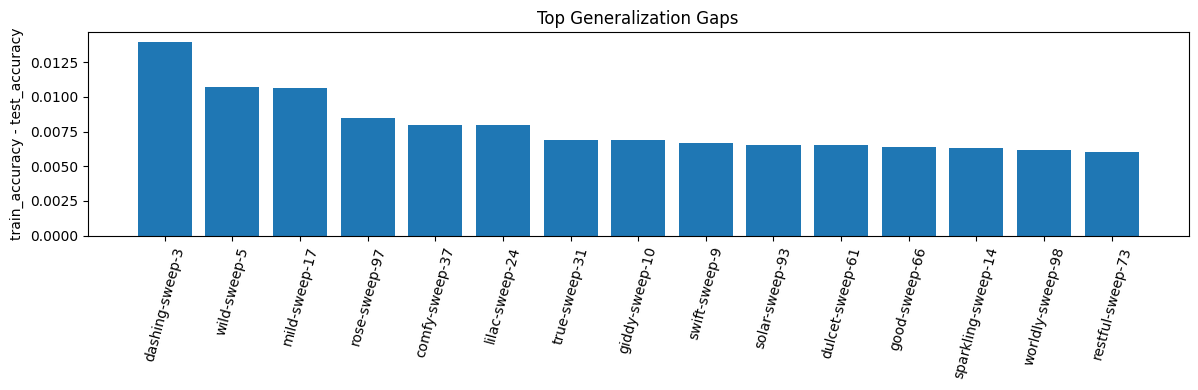

In [4]:
df = pd.DataFrame(rows).sort_values("gap", ascending=False)
display(df.head(15))
import matplotlib.pyplot as plt

top = df.head(15)
plt.figure(figsize=(12,4))
plt.bar(top["run"], top["gap"])
plt.xticks(rotation=75)
plt.ylabel("train_accuracy - test_accuracy")
plt.title("Top Generalization Gaps")
plt.tight_layout()
plt.show()

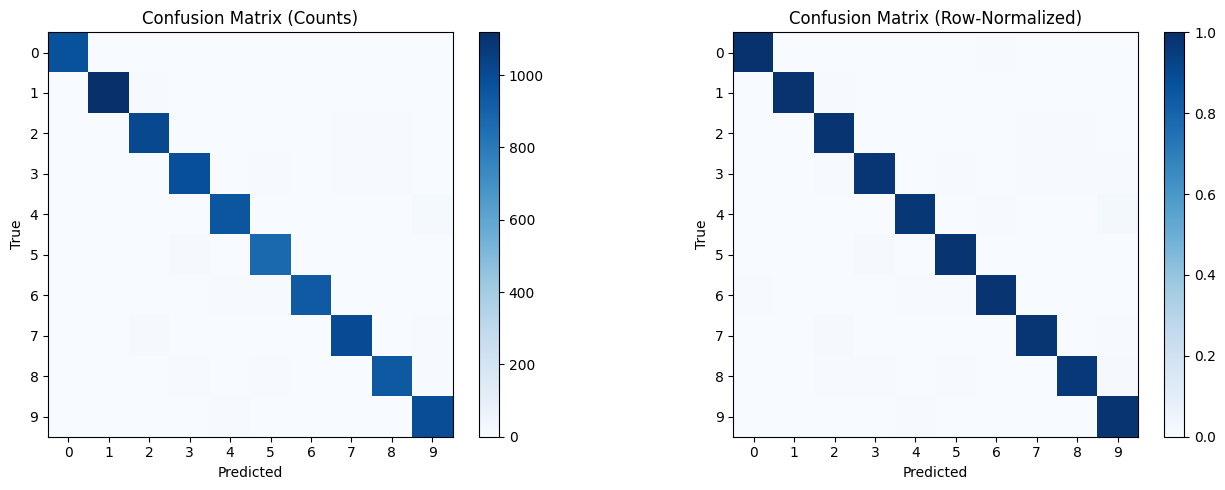

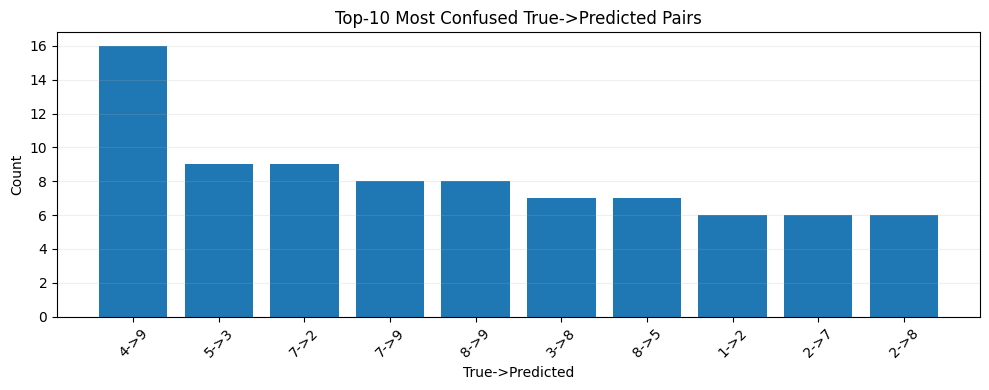

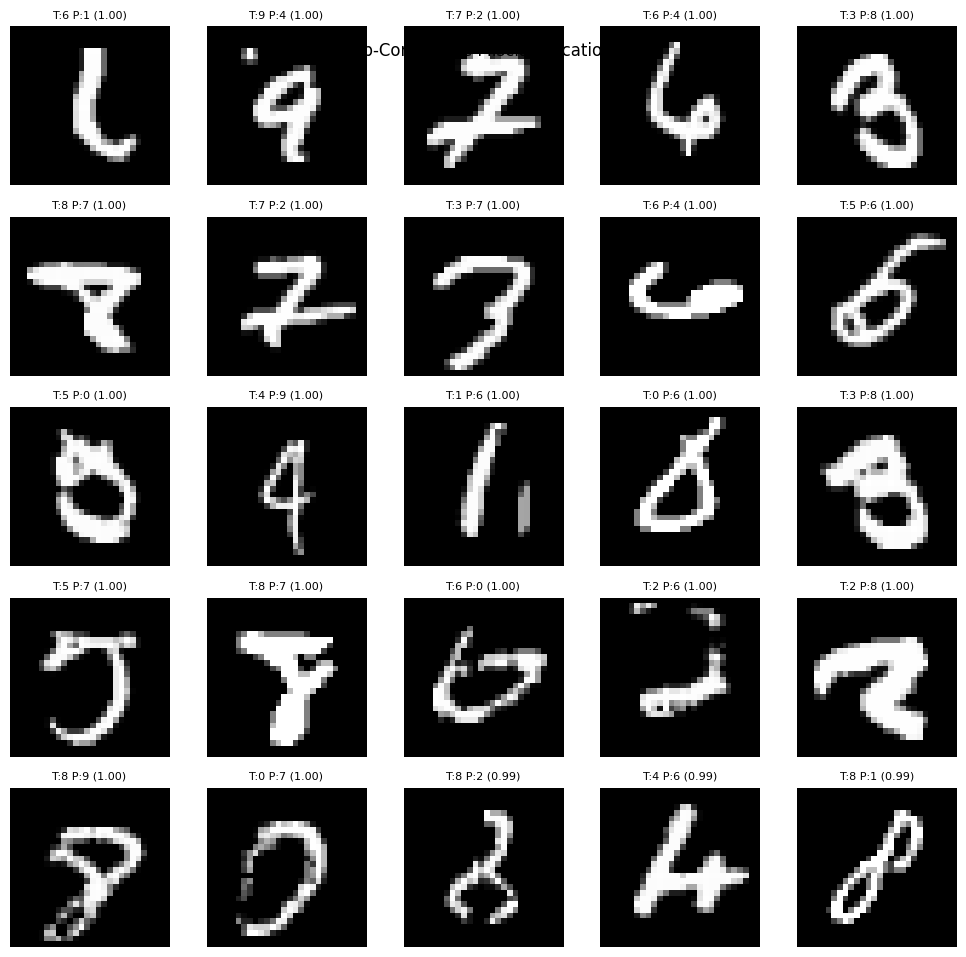

ConfigError: config file c:\Users\Hp\Desktop\DL\da6401_assignment_1\notebooks\wandb\sweep-p9s2ru6f\config-e7117yut.yaml doesn't exist

In [5]:
# Q2.8 Error Analysis + W&B logging

import os
import sys
import json
import numpy as np
import matplotlib.pyplot as plt
import wandb

REPO_ROOT = r"C:\Users\Hp\Desktop\DL\da6401_assignment_1"
PROJECT = "da6401_assignment_1"

src_path = os.path.join(REPO_ROOT, "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

from ann.neural_network import NeuralNetwork
from ann.activations import softmax
from utils.data_loader import load_data

# -------- Load best config/model --------
with open(os.path.join(REPO_ROOT, "src", "best_config.json"), "r", encoding="utf-8") as f:
    cfg = json.load(f)

class Args: pass
args = Args()
for k, v in cfg.items():
    setattr(args, k, v)

model = NeuralNetwork(args)
weights = np.load(os.path.join(REPO_ROOT, "src", "best_model.npy"), allow_pickle=True).item()
model.set_weights(weights)

_, _, _, _, X_test, y_test = load_data(cfg["dataset"])

out = model.evaluate(X_test, y_test)
logits = out["logits"]
preds = np.argmax(logits, axis=1)
probs = softmax(logits)
pred_conf = probs[np.arange(len(preds)), preds]

# -------- Confusion matrix via NumPy --------
num_classes = 10
cm = np.zeros((num_classes, num_classes), dtype=np.int64)
np.add.at(cm, (y_test, preds), 1)

cm_norm = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)

# -------- Figure 1: standard + normalized confusion matrix --------
fig1, ax = plt.subplots(1, 2, figsize=(14, 5))

im0 = ax[0].imshow(cm, cmap="Blues")
ax[0].set_title("Confusion Matrix (Counts)")
ax[0].set_xlabel("Predicted")
ax[0].set_ylabel("True")
ax[0].set_xticks(range(num_classes))
ax[0].set_yticks(range(num_classes))
plt.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)

im1 = ax[1].imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
ax[1].set_title("Confusion Matrix (Row-Normalized)")
ax[1].set_xlabel("Predicted")
ax[1].set_ylabel("True")
ax[1].set_xticks(range(num_classes))
ax[1].set_yticks(range(num_classes))
plt.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

# -------- Figure 2: Top confused class pairs--------
cm_off = cm.copy()
np.fill_diagonal(cm_off, 0)

pairs = []
for i in range(num_classes):
    for j in range(num_classes):
        if i != j and cm_off[i, j] > 0:
            pairs.append((i, j, cm_off[i, j]))

pairs = sorted(pairs, key=lambda x: x[2], reverse=True)[:10]

fig2, ax2 = plt.subplots(figsize=(10, 4))
labels = [f"{a}->{b}" for a, b, _ in pairs]
vals = [v for _, _, v in pairs]
ax2.bar(labels, vals)
ax2.set_title("Top-10 Most Confused True->Predicted Pairs")
ax2.set_xlabel("True->Predicted")
ax2.set_ylabel("Count")
ax2.tick_params(axis="x", rotation=45)
ax2.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

# -------- Figure 3: High-confidence wrong predictions --------
wrong_idx = np.where(preds != y_test)[0]
top_wrong = wrong_idx[np.argsort(pred_conf[wrong_idx])[::-1][:25]]

fig3 = plt.figure(figsize=(10, 10))
for i, idx in enumerate(top_wrong):
    ax3 = fig3.add_subplot(5, 5, i + 1)
    ax3.imshow(X_test[idx].reshape(28, 28), cmap="gray")
    ax3.set_title(f"T:{y_test[idx]} P:{preds[idx]} ({pred_conf[idx]:.2f})", fontsize=8)
    ax3.axis("off")
fig3.suptitle("Top-Confidence Misclassifications", y=0.92)
plt.tight_layout()
plt.show()

# -------- Log to W&B --------
run = wandb.init(project=PROJECT, name="q2_8_error_analysis_best_model", reinit=True, config={"question": "2.8"})
wandb.log({
    "q2_8_confusion_matrices": wandb.Image(fig1),
    "q2_8_top_confused_pairs": wandb.Image(fig2),
    "q2_8_top_confidence_misclassified": wandb.Image(fig3),
    "q2_8_test_accuracy": float(out["accuracy"]),
    "q2_8_test_f1": float(out["f1"]),
    "q2_8_test_loss": float(out["loss"]),
})
wandb.finish()
